# 01_data_audit

This notebook audits the Cholec80 annotations and video metadata before we build pilot splits and extract sampled frames.

## Goals
- Inspect phase annotation structure in more detail
- Measure annotation lengths per video
- Summarize overall class balance
- Check whether annotation rows are indexed by frame number or sampled timepoint
- Compare annotation lengths with video metadata
- Identify the safest alignment strategy for later frame extraction

## Outcome
By the end of this notebook, we should know exactly how to map annotation rows to frames for:
- original videos
- compressed videos

In [1]:
# ============================================================
# 1. Imports
# ============================================================
import json
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 2. Paths
# ============================================================
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "cholec80"

VIDEOS_DIR = DATA_ROOT / "videos"
PHASE_ANN_DIR = DATA_ROOT / "phase_annotations"
TOOL_ANN_DIR = DATA_ROOT / "tool_annotations"

CRF_DIRS = {
    "CRF18": DATA_ROOT / "videos_CRF18",
    "CRF23": DATA_ROOT / "videos_CRF23",
    "CRF28": DATA_ROOT / "videos_CRF28",
    "CRF35": DATA_ROOT / "videos_CRF35",
    "CRF51": DATA_ROOT / "videos_CRF51",
}

SPLITS_DIR = DATA_ROOT / "splits"
OUTPUTS_DIR = DATA_ROOT / "outputs"
AUDIT_OUT_DIR = OUTPUTS_DIR / "data_audit"
AUDIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ============================================================
# 3. Phase mapping
# ============================================================
PHASE_MAP = {
    "Preparation": 0,
    "CalotTriangleDissection": 1,
    "ClippingCutting": 2,
    "GallbladderDissection": 3,
    "GallbladderPackaging": 4,
    "CleaningCoagulation": 5,
    "GallbladderRetraction": 6,
}
ID_TO_PHASE = {v: k for k, v in PHASE_MAP.items()}
NUM_CLASSES = len(PHASE_MAP)

In [4]:
# ============================================================
# 4. Helpers
# ============================================================
def parse_phase_file(phase_file: Path) -> pd.DataFrame:
    rows = []
    with open(phase_file, "r") as f:
        lines = f.readlines()

    if lines and ("Frame" in lines[0] or "Phase" in lines[0]):
        lines = lines[1:]

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 2:
            continue

        frame_idx = int(parts[0])
        phase_name = parts[1].strip()

        rows.append({
            "frame_idx": frame_idx,
            "phase_name": phase_name,
            "phase_id": PHASE_MAP.get(phase_name, -1),
        })

    return pd.DataFrame(rows)


def ffprobe_video(video_path: Path):
    cmd = [
        "ffprobe",
        "-v", "error",
        "-select_streams", "v:0",
        "-show_entries",
        "stream=width,height,r_frame_rate,avg_frame_rate,nb_frames,duration",
        "-of", "json",
        str(video_path),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    return json.loads(result.stdout)


def frac_to_float(s):
    if isinstance(s, (int, float)):
        return float(s)
    if "/" in str(s):
        a, b = s.split("/")
        return float(a) / float(b)
    return float(s)

## Inspect a few raw annotation files

In [5]:
# ============================================================
# 5. Show first few lines of a few annotation files
# ============================================================
for vid in ["video01", "video10", "video40"]:
    phase_file = PHASE_ANN_DIR / f"{vid}-phase.txt"
    print(f"\n===== {phase_file.name} =====")
    with open(phase_file, "r") as f:
        for i, line in enumerate(f):
            print(repr(line.rstrip("\n")))
            if i >= 9:
                break


===== video01-phase.txt =====
'Frame\tPhase'
'0\tPreparation'
'1\tPreparation'
'2\tPreparation'
'3\tPreparation'
'4\tPreparation'
'5\tPreparation'
'6\tPreparation'
'7\tPreparation'
'8\tPreparation'

===== video10-phase.txt =====
'Frame\tPhase'
'0\tCalotTriangleDissection'
'1\tCalotTriangleDissection'
'2\tCalotTriangleDissection'
'3\tCalotTriangleDissection'
'4\tCalotTriangleDissection'
'5\tCalotTriangleDissection'
'6\tCalotTriangleDissection'
'7\tCalotTriangleDissection'
'8\tCalotTriangleDissection'

===== video40-phase.txt =====
'Frame\tPhase'
'0\tPreparation'
'1\tPreparation'
'2\tPreparation'
'3\tPreparation'
'4\tPreparation'
'5\tPreparation'
'6\tPreparation'
'7\tPreparation'
'8\tPreparation'


In [6]:
# ============================================================
# 6. Parse all phase annotation files
# ============================================================
all_phase_tables = []

for phase_file in sorted(PHASE_ANN_DIR.glob("video*-phase.txt")):
    video_name = phase_file.name.replace("-phase.txt", "")
    df = parse_phase_file(phase_file)
    df["video"] = video_name
    all_phase_tables.append(df)

all_phase_df = pd.concat(all_phase_tables, ignore_index=True)

print("Total rows:", len(all_phase_df))
print("Unique videos:", all_phase_df["video"].nunique())
print("Unique labels:", sorted(all_phase_df["phase_name"].unique()))
all_phase_df.head()

Total rows: 4612532
Unique videos: 80
Unique labels: ['CalotTriangleDissection', 'CleaningCoagulation', 'ClippingCutting', 'GallbladderDissection', 'GallbladderPackaging', 'GallbladderRetraction', 'Preparation']


,frame_idx,phase_name,phase_id,video
0,0,Preparation,0,video01
1,1,Preparation,0,video01
2,2,Preparation,0,video01
3,3,Preparation,0,video01
4,4,Preparation,0,video01


In [7]:
# ============================================================
# 7. Check frame_idx properties
# ============================================================
frame_idx_summary = (
    all_phase_df.groupby("video")["frame_idx"]
    .agg(["min", "max", "nunique"])
    .reset_index()
    .sort_values("video")
    .reset_index(drop=True)
)

frame_idx_summary.head(10)

,video,min,max,nunique
0,video01,0,43325,43326
1,video02,0,70975,70976
2,video03,0,145700,145701
3,video04,0,38050,38051
4,video05,0,58600,58601
5,video06,0,53825,53826
6,video07,0,113925,113926
7,video08,0,37975,37976
8,video09,0,67550,67551
9,video10,0,43725,43726


In [8]:
# ============================================================
# 8. Check frame_idx step size per video
# ============================================================
step_rows = []

for video, group in all_phase_df.groupby("video"):
    group = group.sort_values("frame_idx").reset_index(drop=True)
    diffs = group["frame_idx"].diff().dropna()

    step_rows.append({
        "video": video,
        "num_rows": len(group),
        "min_frame_idx": int(group["frame_idx"].min()),
        "max_frame_idx": int(group["frame_idx"].max()),
        "unique_step_sizes": sorted(diffs.unique().tolist())[:10],
        "most_common_step": int(diffs.mode().iloc[0]) if len(diffs) > 0 else None,
    })

step_df = pd.DataFrame(step_rows).sort_values("video").reset_index(drop=True)
step_df.head(10)

,video,num_rows,min_frame_idx,max_frame_idx,unique_step_sizes,most_common_step
0,video01,43326,0,43325,[1.0],1
1,video02,70976,0,70975,[1.0],1
2,video03,145701,0,145700,[1.0],1
3,video04,38051,0,38050,[1.0],1
4,video05,58601,0,58600,[1.0],1
5,video06,53826,0,53825,[1.0],1
6,video07,113926,0,113925,[1.0],1
7,video08,37976,0,37975,[1.0],1
8,video09,67551,0,67550,[1.0],1
9,video10,43726,0,43725,[1.0],1


## This is the key question:
Are annotation rows indexed like 0,1,2,... or 0,25,50,... ?

In [9]:
# ============================================================
# 9. Check if annotations are sampled every 25 frames
# ============================================================
step_counts = {}

for video, group in all_phase_df.groupby("video"):
    group = group.sort_values("frame_idx").reset_index(drop=True)
    diffs = group["frame_idx"].diff().dropna()
    vc = diffs.value_counts().to_dict()
    step_counts[video] = vc

step_count_df = pd.DataFrame(step_counts).fillna(0).astype(int).T
step_count_df.head(10)

,1.0
video01,43325
video02,70975
video03,145700
video04,38050
video05,58600
video06,53825
video07,113925
video08,37975
video09,67550
video10,43725


In [10]:
# ============================================================
# 10. Overall annotation label distribution
# ============================================================
label_counts = (
    all_phase_df["phase_name"]
    .value_counts()
    .sort_values(ascending=False)
)

label_counts

phase_name
CalotTriangleDissection    1870651
GallbladderDissection      1460825
CleaningCoagulation         358303
ClippingCutting             352000
Preparation                 214301
GallbladderPackaging        190450
GallbladderRetraction       166002
Name: count, dtype: int64

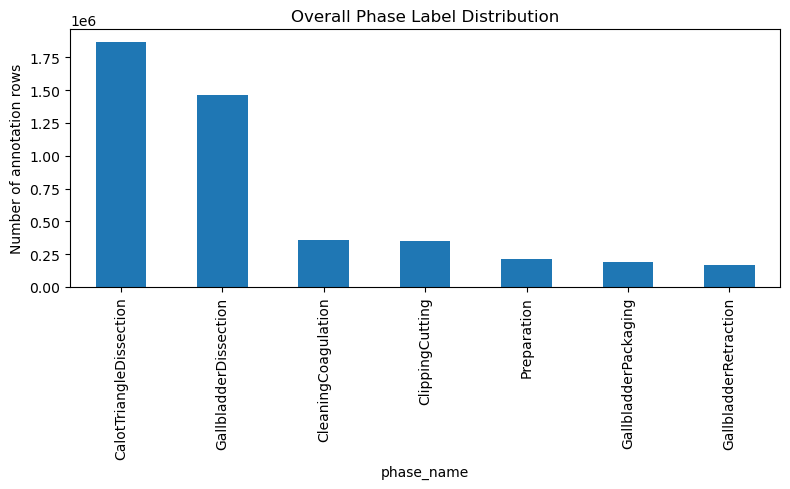

In [11]:
# ============================================================
# 11. Plot overall label distribution
# ============================================================
plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.ylabel("Number of annotation rows")
plt.title("Overall Phase Label Distribution")
plt.tight_layout()
plt.savefig(AUDIT_OUT_DIR / "overall_phase_distribution.png", dpi=200)
plt.show()

In [12]:
# ============================================================
# 12. Per-video annotation row counts
# ============================================================
per_video_counts = (
    all_phase_df.groupby("video")
    .size()
    .reset_index(name="num_annotation_rows")
    .sort_values("video")
    .reset_index(drop=True)
)

per_video_counts.head(20)

,video,num_annotation_rows
0,video01,43326
1,video02,70976
2,video03,145701
3,video04,38051
4,video05,58601
5,video06,53826
6,video07,113926
7,video08,37976
8,video09,67551
9,video10,43726


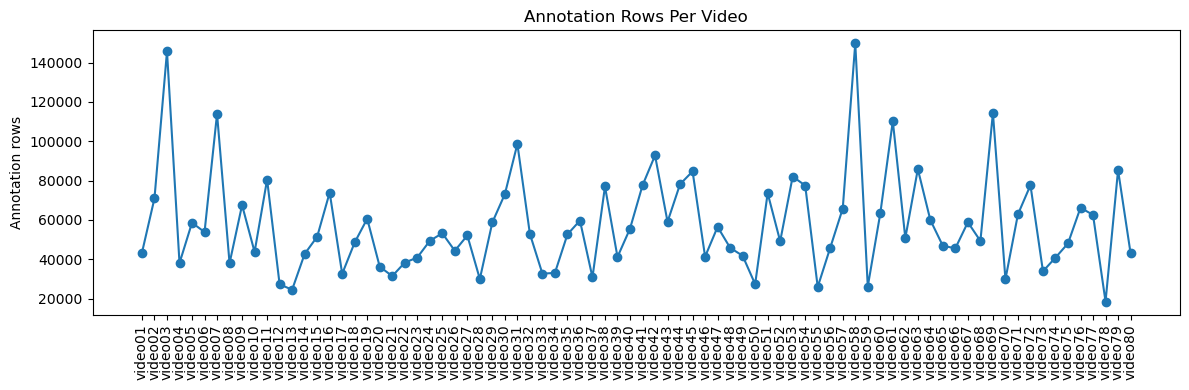

In [13]:
# ============================================================
# 13. Plot annotation row counts by video
# ============================================================
plt.figure(figsize=(12, 4))
plt.plot(per_video_counts["video"], per_video_counts["num_annotation_rows"], marker="o")
plt.xticks(rotation=90)
plt.ylabel("Annotation rows")
plt.title("Annotation Rows Per Video")
plt.tight_layout()
plt.savefig(AUDIT_OUT_DIR / "annotation_rows_per_video.png", dpi=200)
plt.show()

## Probe original video metadata

In [14]:
# ============================================================
# 14. Collect original video metadata
# ============================================================
video_rows = []

for video_file in sorted(VIDEOS_DIR.glob("video*.mp4")):
    meta = ffprobe_video(video_file)
    stream = meta["streams"][0]

    width = int(stream["width"])
    height = int(stream["height"])
    r_frame_rate = frac_to_float(stream["r_frame_rate"])
    avg_frame_rate = frac_to_float(stream["avg_frame_rate"])
    duration = float(stream["duration"]) if "duration" in stream else np.nan

    nb_frames_raw = stream.get("nb_frames", None)
    nb_frames = int(nb_frames_raw) if nb_frames_raw not in [None, "N/A"] else np.nan

    video_rows.append({
        "video": video_file.stem,
        "width": width,
        "height": height,
        "r_frame_rate": r_frame_rate,
        "avg_frame_rate": avg_frame_rate,
        "duration_sec": duration,
        "nb_frames": nb_frames,
    })

video_meta_df = pd.DataFrame(video_rows).sort_values("video").reset_index(drop=True)
video_meta_df.head()

,video,width,height,r_frame_rate,avg_frame_rate,duration_sec,nb_frames
0,video01,854,480,25.0,25.0,1733.04,43326
1,video02,854,480,25.0,25.0,2839.04,70976
2,video03,854,480,25.0,25.0,5828.04,145701
3,video04,854,480,25.0,25.0,1522.04,38051
4,video05,854,480,25.0,25.0,2344.04,58601


In [15]:
# ============================================================
# 15. Basic video metadata summary
# ============================================================
video_meta_df.describe(include="all")

,video,width,height,r_frame_rate,avg_frame_rate,duration_sec,nb_frames
count,80,80.000000,80.000000,80.0,80.0,80.000000,80.000000
unique,80,NaN,NaN,NaN,NaN,NaN,NaN
top,video01,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,893.975000,502.500000,25.0,25.0,2306.265000,57656.625000
std,NaN,203.800223,114.709319,0.0,0.0,1025.529057,25638.226434
min,NaN,854.000000,480.000000,25.0,25.0,739.040000,18476.000000
25%,NaN,854.000000,480.000000,25.0,25.0,1644.040000,41101.000000
50%,NaN,854.000000,480.000000,25.0,25.0,2095.040000,52376.000000
75%,NaN,854.000000,480.000000,25.0,25.0,2860.540000,71513.500000


In [16]:
# ============================================================
# 16. Merge video metadata with annotation counts
# ============================================================
audit_df = per_video_counts.merge(video_meta_df, on="video", how="inner")

audit_df["rows_per_second"] = audit_df["num_annotation_rows"] / audit_df["duration_sec"]
audit_df["frames_per_annotation"] = audit_df["nb_frames"] / audit_df["num_annotation_rows"]

audit_df.head(10)

,video,num_annotation_rows,width,height,r_frame_rate,avg_frame_rate,duration_sec,nb_frames,rows_per_second,frames_per_annotation
0,video01,43326,854,480,25.0,25.0,1733.04,43326,25.0,1.0
1,video02,70976,854,480,25.0,25.0,2839.04,70976,25.0,1.0
2,video03,145701,854,480,25.0,25.0,5828.04,145701,25.0,1.0
3,video04,38051,854,480,25.0,25.0,1522.04,38051,25.0,1.0
4,video05,58601,854,480,25.0,25.0,2344.04,58601,25.0,1.0
5,video06,53826,854,480,25.0,25.0,2153.04,53826,25.0,1.0
6,video07,113926,854,480,25.0,25.0,4557.04,113926,25.0,1.0
7,video08,37976,854,480,25.0,25.0,1519.04,37976,25.0,1.0
8,video09,67551,854,480,25.0,25.0,2702.04,67551,25.0,1.0
9,video10,43726,854,480,25.0,25.0,1749.04,43726,25.0,1.0


## The most important derived quantities
- `rows_per_second` tells us annotation sampling density in time
- `frames_per_annotation` tells us how many raw video frames correspond to one annotation row

In [17]:
# ============================================================
# 17. Summary of alignment quantities
# ============================================================
audit_df[["rows_per_second", "frames_per_annotation", "avg_frame_rate"]].describe()

,rows_per_second,frames_per_annotation,avg_frame_rate
count,80.000000,80.000000,80.0
mean,25.000016,0.999999,25.0
std,0.000105,0.000004,0.0
min,25.000000,0.999968,25.0
25%,25.000000,1.000000,25.0
50%,25.000000,1.000000,25.0
75%,25.000000,1.000000,25.0
max,25.000812,1.000000,25.0


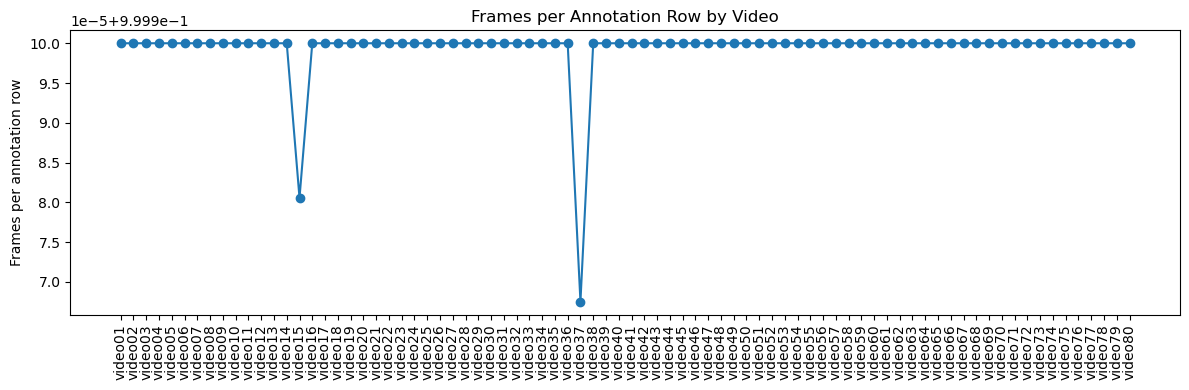

In [19]:
# ============================================================
# 18. Plot frames_per_annotation
# ============================================================
plt.figure(figsize=(12, 4))
plt.plot(audit_df["video"], audit_df["frames_per_annotation"], marker="o")
plt.xticks(rotation=90)
plt.ylabel("Frames per annotation row")
plt.title("Frames per Annotation Row by Video")
plt.tight_layout()
plt.savefig(AUDIT_OUT_DIR / "frames_per_annotation_by_video.png", dpi=200)
plt.show()

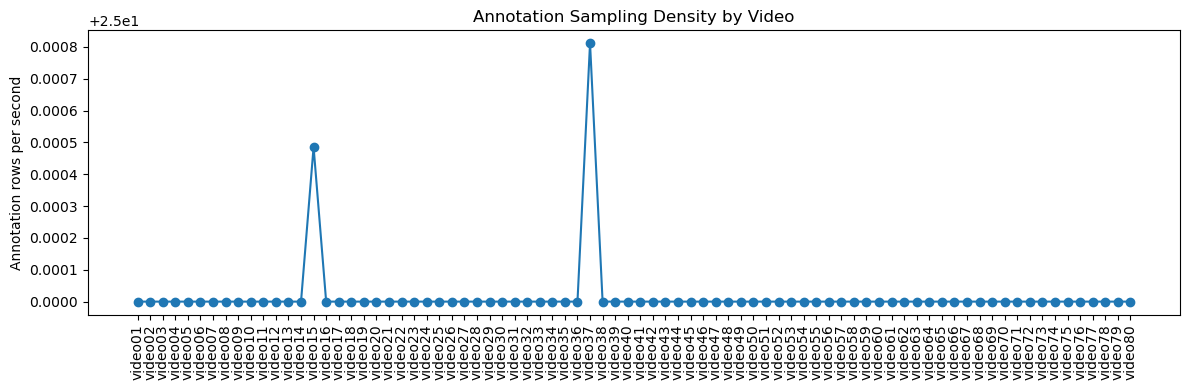

In [20]:
# ============================================================
# 19. Plot rows_per_second
# ============================================================
plt.figure(figsize=(12, 4))
plt.plot(audit_df["video"], audit_df["rows_per_second"], marker="o")
plt.xticks(rotation=90)
plt.ylabel("Annotation rows per second")
plt.title("Annotation Sampling Density by Video")
plt.tight_layout()
plt.savefig(AUDIT_OUT_DIR / "rows_per_second_by_video.png", dpi=200)
plt.show()

In [21]:
# ============================================================
# 20. Check whether frame_idx max is close to nb_frames
# ============================================================
audit_df["frame_idx_vs_nb_frames_gap"] = audit_df["nb_frames"] - audit_df["frame_idx"].max() if False else np.nan

In [22]:
# ============================================================
# 21. Build per-video frame_idx summary and merge it properly
# ============================================================
frame_idx_video_summary = (
    all_phase_df.groupby("video")["frame_idx"]
    .agg(frame_idx_min="min", frame_idx_max="max", frame_idx_nunique="nunique")
    .reset_index()
)

audit_df = audit_df.drop(columns=[c for c in ["frame_idx_vs_nb_frames_gap"] if c in audit_df.columns])
audit_df = audit_df.merge(frame_idx_video_summary, on="video", how="left")

audit_df["nb_frames_minus_frame_idx_max"] = audit_df["nb_frames"] - audit_df["frame_idx_max"]
audit_df.head(10)

,video,num_annotation_rows,width,height,r_frame_rate,avg_frame_rate,duration_sec,nb_frames,rows_per_second,frames_per_annotation,frame_idx_min,frame_idx_max,frame_idx_nunique,nb_frames_minus_frame_idx_max
0,video01,43326,854,480,25.0,25.0,1733.04,43326,25.0,1.0,0,43325,43326,1
1,video02,70976,854,480,25.0,25.0,2839.04,70976,25.0,1.0,0,70975,70976,1
2,video03,145701,854,480,25.0,25.0,5828.04,145701,25.0,1.0,0,145700,145701,1
3,video04,38051,854,480,25.0,25.0,1522.04,38051,25.0,1.0,0,38050,38051,1
4,video05,58601,854,480,25.0,25.0,2344.04,58601,25.0,1.0,0,58600,58601,1
5,video06,53826,854,480,25.0,25.0,2153.04,53826,25.0,1.0,0,53825,53826,1
6,video07,113926,854,480,25.0,25.0,4557.04,113926,25.0,1.0,0,113925,113926,1
7,video08,37976,854,480,25.0,25.0,1519.04,37976,25.0,1.0,0,37975,37976,1
8,video09,67551,854,480,25.0,25.0,2702.04,67551,25.0,1.0,0,67550,67551,1
9,video10,43726,854,480,25.0,25.0,1749.04,43726,25.0,1.0,0,43725,43726,1


In [23]:
# ============================================================
# 22. Inspect alignment columns
# ============================================================
audit_df[
    [
        "video",
        "num_annotation_rows",
        "duration_sec",
        "nb_frames",
        "avg_frame_rate",
        "frame_idx_min",
        "frame_idx_max",
        "frame_idx_nunique",
        "rows_per_second",
        "frames_per_annotation",
        "nb_frames_minus_frame_idx_max",
    ]
].head(20)

,video,num_annotation_rows,duration_sec,nb_frames,avg_frame_rate,frame_idx_min,frame_idx_max,frame_idx_nunique,rows_per_second,frames_per_annotation,nb_frames_minus_frame_idx_max
0,video01,43326,1733.04,43326,25.0,0,43325,43326,25.000000,1.000000,1
1,video02,70976,2839.04,70976,25.0,0,70975,70976,25.000000,1.000000,1
2,video03,145701,5828.04,145701,25.0,0,145700,145701,25.000000,1.000000,1
3,video04,38051,1522.04,38051,25.0,0,38050,38051,25.000000,1.000000,1
4,video05,58601,2344.04,58601,25.0,0,58600,58601,25.000000,1.000000,1
5,video06,53826,2153.04,53826,25.0,0,53825,53826,25.000000,1.000000,1
6,video07,113926,4557.04,113926,25.0,0,113925,113926,25.000000,1.000000,1
7,video08,37976,1519.04,37976,25.0,0,37975,37976,25.000000,1.000000,1
8,video09,67551,2702.04,67551,25.0,0,67550,67551,25.000000,1.000000,1
9,video10,43726,1749.04,43726,25.0,0,43725,43726,25.000000,1.000000,1


## Interpretation guide

Typical outcomes:

### Case A
If:
- `frame_idx` increases by 25
- `frames_per_annotation` is about 25
- `rows_per_second` is about 1
- `avg_frame_rate` is about 25

Then annotation files are likely indexed in **raw frame numbers sampled at 1 fps**.

### Case B
If:
- `frame_idx` increases by 1
- `frames_per_annotation` is about 25
- `rows_per_second` is about 1

Then annotation files are likely indexed by **annotation row number**, not raw frame number.

This notebook tells us which case your dataset actually follows.

In [24]:
# ============================================================
# 23. Check a few specific videos in detail
# ============================================================
for vid in ["video01", "video10", "video40", "video80"]:
    print("\n==============================")
    print(vid)
    print("==============================")
    display(
        audit_df[audit_df["video"] == vid][
            [
                "video",
                "num_annotation_rows",
                "duration_sec",
                "nb_frames",
                "avg_frame_rate",
                "frame_idx_min",
                "frame_idx_max",
                "frame_idx_nunique",
                "rows_per_second",
                "frames_per_annotation",
                "nb_frames_minus_frame_idx_max",
            ]
        ]
    )


video01


,video,num_annotation_rows,duration_sec,nb_frames,avg_frame_rate,frame_idx_min,frame_idx_max,frame_idx_nunique,rows_per_second,frames_per_annotation,nb_frames_minus_frame_idx_max
0,video01,43326,1733.04,43326,25.0,0,43325,43326,25.0,1.0,1



video10


,video,num_annotation_rows,duration_sec,nb_frames,avg_frame_rate,frame_idx_min,frame_idx_max,frame_idx_nunique,rows_per_second,frames_per_annotation,nb_frames_minus_frame_idx_max
9,video10,43726,1749.04,43726,25.0,0,43725,43726,25.0,1.0,1



video40


,video,num_annotation_rows,duration_sec,nb_frames,avg_frame_rate,frame_idx_min,frame_idx_max,frame_idx_nunique,rows_per_second,frames_per_annotation,nb_frames_minus_frame_idx_max
39,video40,55551,2222.04,55551,25.0,0,55550,55551,25.0,1.0,1



video80


,video,num_annotation_rows,duration_sec,nb_frames,avg_frame_rate,frame_idx_min,frame_idx_max,frame_idx_nunique,rows_per_second,frames_per_annotation,nb_frames_minus_frame_idx_max
79,video80,43101,1724.04,43101,25.0,0,43100,43101,25.0,1.0,1


In [25]:
# ============================================================
# 24. Save audit tables
# ============================================================
all_phase_df.to_csv(AUDIT_OUT_DIR / "all_phase_annotations_long.csv", index=False)
video_meta_df.to_csv(AUDIT_OUT_DIR / "video_metadata.csv", index=False)
audit_df.to_csv(AUDIT_OUT_DIR / "annotation_video_alignment_audit.csv", index=False)

print("Saved:")
print(AUDIT_OUT_DIR / "all_phase_annotations_long.csv")
print(AUDIT_OUT_DIR / "video_metadata.csv")
print(AUDIT_OUT_DIR / "annotation_video_alignment_audit.csv")

Saved:
/Users/niranjani/Desktop/video-compression-project/cholec80/outputs/data_audit/all_phase_annotations_long.csv
/Users/niranjani/Desktop/video-compression-project/cholec80/outputs/data_audit/video_metadata.csv
/Users/niranjani/Desktop/video-compression-project/cholec80/outputs/data_audit/annotation_video_alignment_audit.csv
